In [79]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.image as mpimg
import numpy as np


In [72]:
with open("data.txt", "r", encoding="utf-8") as f:
    lignes_modifiees = []
    for ligne in f:
        colonnes = ligne.split()
        lignes_modifiees.append(";".join(colonnes))

with open("data.txt", "w", encoding="utf-8") as f:
    for ligne in lignes_modifiees:
        f.write(ligne + "\n")

In [73]:


df = pd.read_csv("data.txt", sep=";")
print(df.head())

   Vitess_Vent_[m/s]  Dir_Vent_[deg]  Pelec[w]  Patm[Pa]  Temp[degC]  Statut
0                4.4             221     35857    100782        -1.2       1
1                8.1             325    228431    101925         2.5       1
2                1.6              14         0    102126         7.5       1
3                1.3             235         0    100436        -1.3       0
4                3.0              80         0    100317        14.4       1


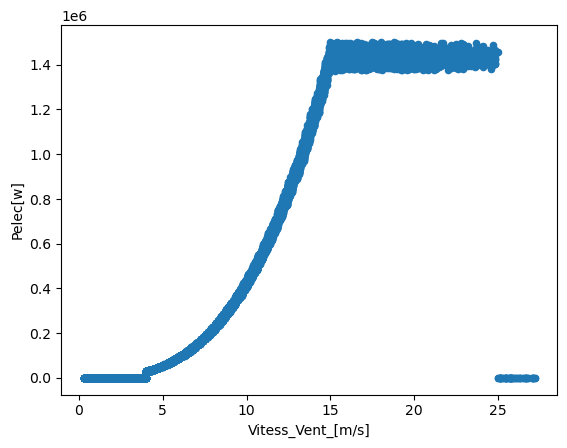

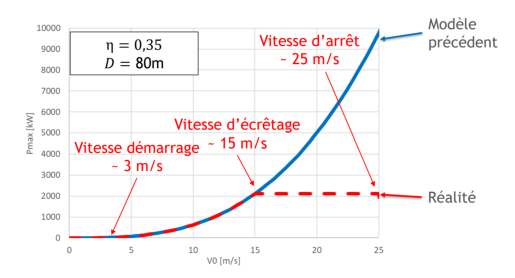

In [74]:
data1 = df[["Vitess_Vent_[m/s]", "Pelec[w]"]]
data1.plot(x="Vitess_Vent_[m/s]", y="Pelec[w]", kind="scatter")
plt.show()

img = mpimg.imread("courbe(P(v))_modele.png")   # ou .jpg, .jpeg...
plt.imshow(img)
plt.axis("off")   # retire les axes
plt.show()



       Vitess_Vent_[m/s]  Pelec[w]  Temp[degC]
118                 10.0    433841        -1.6
761                 10.0    431565         1.0
853                 10.0    429058        -0.6
961                 10.0    432442         0.5
967                 10.0    447105        -3.9
...                  ...       ...         ...
19213               10.0    440856        -4.3
19477               10.0    427474         4.3
19613               10.0    427662         1.0
19859               10.0    426513         4.4
19910               10.0    432175        -0.7

[142 rows x 3 columns]
            Temp[degC]  Pelec[w]
Temp[degC]    1.000000 -0.905194
Pelec[w]     -0.905194  1.000000


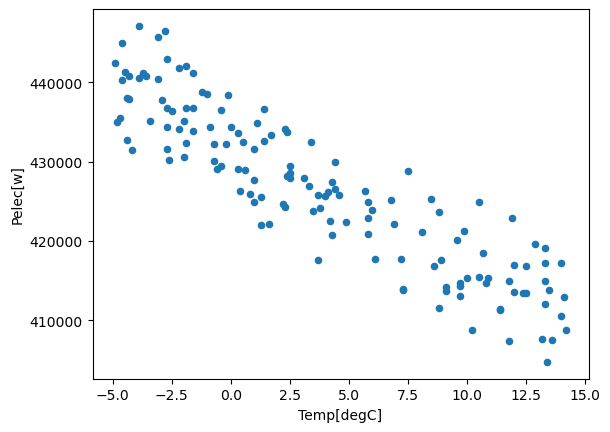

In [96]:
data2 = df[["Vitess_Vent_[m/s]", "Pelec[w]", "Temp[degC]"]]

data2bis = data2[(data2["Vitess_Vent_[m/s]"] == 10) ]
print(data2bis)
data2bis.plot(
    x="Temp[degC]",
    y="Pelec[w]",
    kind="scatter"
)


    
print(data2bis[["Temp[degC]", "Pelec[w]"]].corr())

Pente (a) : -766.759325915218
Ordonnée à l'origine (b) : 229703.27411337016
Équation : y = -766.7593 * x + 229703.2741


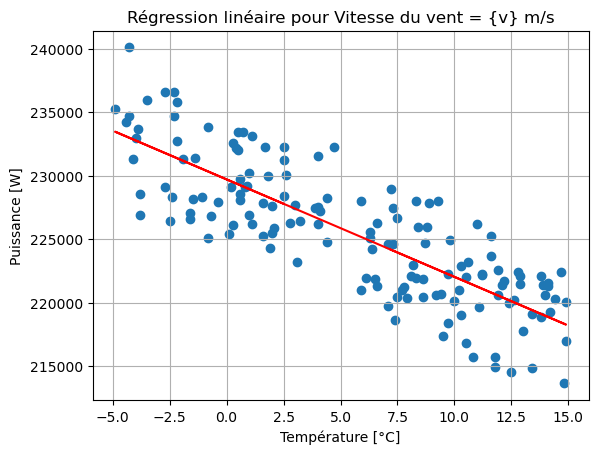

Pente (a) : -1551.5390820933867
Ordonnée à l'origine (b) : 432406.46824730834
Équation : y = -1551.5391 * x + 432406.4682


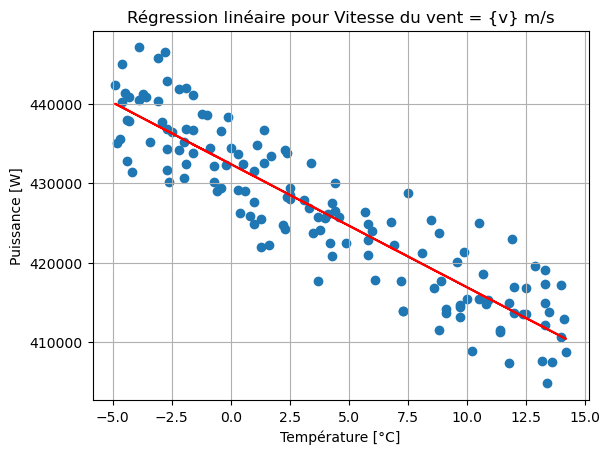

In [ ]:

data4 = df[["Pelec[w]", "Temp[degC]", "Vitess_Vent_[m/s]"]]
vitesse = [8.1, 10]
for v in vitesse :
    data4bis = data4[data4["Vitess_Vent_[m/s]"] == v]

    # Régression linéaire
    x = data4bis["Temp[degC]"]
    y = data4bis["Pelec[w]"]

    coef = np.polyfit(x, y, 1)
    poly = np.poly1d(coef)

    # coeff de la régression
    print("Pente (a) :", coef[0])
    print("Ordonnée à l'origine (b) :", coef[1])
    print(f"Équation : y = {coef[0]:.4f} * x + {coef[1]:.4f}")



    # Affichage
    plt.scatter(x, y)
    plt.plot(x, poly(x), color="red")

    plt.xlabel("Température [°C]")
    plt.ylabel("Puissance [W]")
    plt.title("Régression linéaire pour Vitesse du vent = {v} m/s")
    plt.grid(True) 
    plt.show()


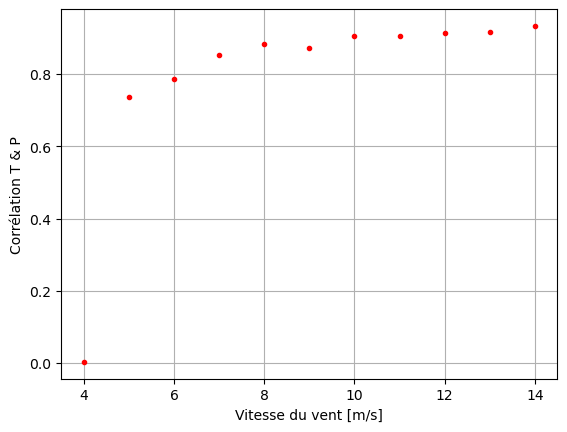

In [121]:
correlation = []
data2 = df[["Vitess_Vent_[m/s]", "Pelec[w]", "Temp[degC]"]]

for i in range(3, 15):
    # Filtrer les lignes où la vitesse du vent vaut i
    data2p = data2[data2["Vitess_Vent_[m/s]"] == i]

    # Vérifier qu'il y a des données
    if len(data2p) > 1:  # au moins 2 points pour corrélation
        corr = data2p[["Temp[degC]", "Pelec[w]"]].corr().loc["Temp[degC]", "Pelec[w]"]
        correlation.append(abs(corr))
    else:
        correlation.append(None)  # pas de données → pas de corrélation

plt.plot(range(3, 3 + len(correlation)), correlation, ".r")
plt.xlabel("Vitesse du vent [m/s]")
plt.ylabel("Corrélation T & P")
plt.grid(True)
plt.show()


       Vitess_Vent_[m/s]  Pelec[w]  Patm[Pa]
1                    8.1    228431    101925
270                  8.1    226164    101365
281                  8.1    227842    100302
441                  8.1    232235    101893
465                  8.1    223684    100974
...                  ...       ...       ...
19706                8.1    229716    101243
19731                8.1    219063    100381
19750                8.1    226209    101915
19762                8.1    229146    100406
19788                8.1    228965    101781

[147 rows x 3 columns]


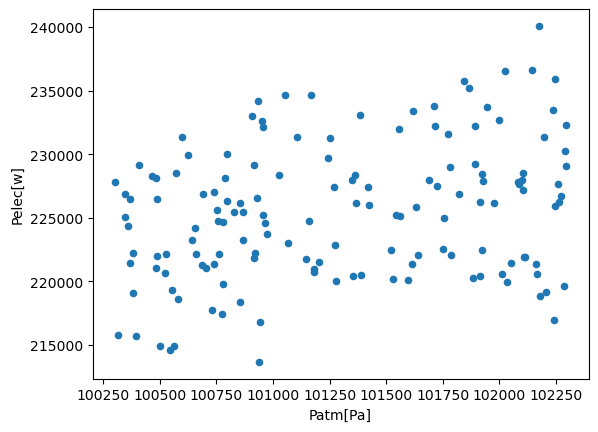

l'indice de corrélation est de 0.29003998544502496


In [100]:
data3 = df[["Vitess_Vent_[m/s]", "Pelec[w]", "Patm[Pa]"]]
data3 = df[["Vitess_Vent_[m/s]", "Pelec[w]", "Patm[Pa]"]]

data3bis = data3[(data3["Vitess_Vent_[m/s]"] == 8.1) ]
print(data3bis)
data3bis.plot(
    x="Patm[Pa]",
    y="Pelec[w]",
    kind="scatter"
)

plt.show()
print("l'indice de corrélation est de", data3bis[["Patm[Pa]", "Pelec[w]"]].corr().loc["Patm[Pa]", "Pelec[w]"])

       Vitess_Vent_[m/s]  Pelec[w]  Dir_Vent_[deg]
0                    4.4     35857             221
1                    8.1    228431             325
2                    1.6         0              14
3                    1.3         0             235
4                    3.0         0              80
...                  ...       ...             ...
19913               14.3   1239022             166
19914                4.3     34445             184
19915               11.5    660867             169
19916                5.2     58428              18
19917               12.0    742723             228

[19918 rows x 3 columns]
l'indice de corrélation est de 0.12180491966481691


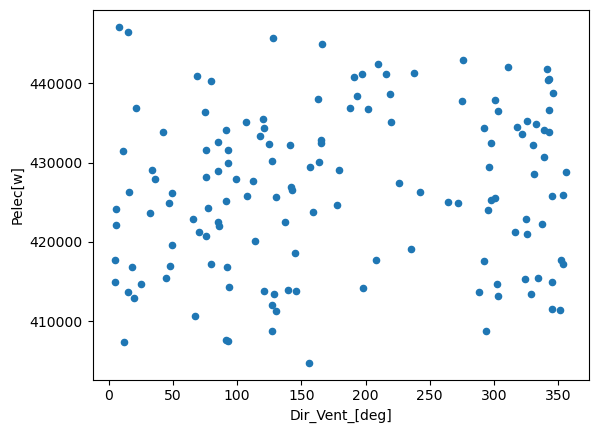

In [109]:
data5 = df[["Vitess_Vent_[m/s]", "Pelec[w]", "Dir_Vent_[deg]"]]
print(data5)
data5bis= df[["Vitess_Vent_[m/s]", "Pelec[w]", "Dir_Vent_[deg]"]]
data5bis= data5bis[data5bis["Vitess_Vent_[m/s]"]==10]
data5bis.plot("Dir_Vent_[deg]","Pelec[w]", kind = "scatter" )
print("l'indice de corrélation est de", data5bis[["Dir_Vent_[deg]", "Pelec[w]"]].corr().loc["Dir_Vent_[deg]", "Pelec[w]"])

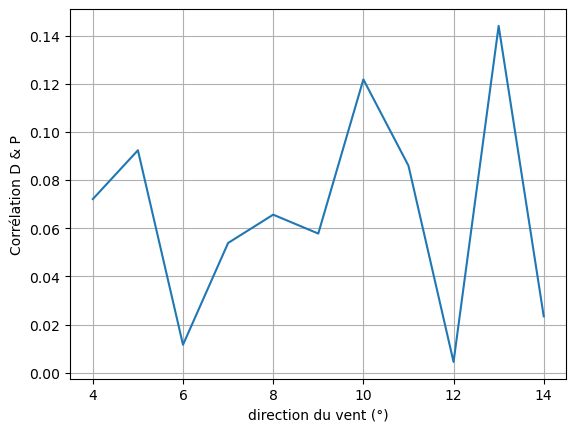

In [122]:
correlation = []
data5 = df[["Vitess_Vent_[m/s]", "Pelec[w]", "Dir_Vent_[deg]"]]

for i in range(3, 15):
    # Filtrer les lignes où la vitesse du vent vaut i
    data5p = data5[data5["Vitess_Vent_[m/s]"] == i]

    # Vérifier qu'il y a des données
    if len(data5p) > 1:  # au moins 2 points pour corrélation
        corr = data5p[["Dir_Vent_[deg]", "Pelec[w]"]].corr().loc["Dir_Vent_[deg]", "Pelec[w]"]
        correlation.append(abs(corr))
    else:
        correlation.append(None)  # pas de données → pas de corrélation

plt.plot(range(3, 3 + len(correlation)), correlation)
plt.xlabel("direction du vent (°)")
plt.ylabel("Corrélation D & P")
plt.grid(True)
plt.show()


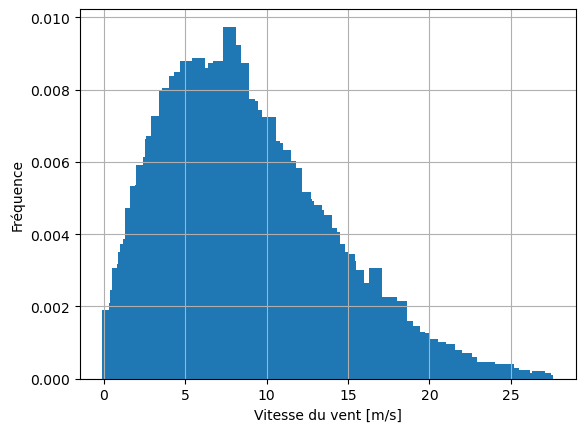

[7.7, 8.0, 5.8, 7.1, 5.1, 6.8, 8.5, 5.4, 6.3, 4.7, 4.4, 6.5, 6.4, 5.5, 4.9, 4.0, 5.9, 6.9, 6.6, 5.6, 3.8, 6.1, 6.2, 6.0, 7.5, 7.3, 5.3, 7.8, 7.0, 8.9, 9.1, 5.0, 7.9, 5.2, 6.7, 5.7, 8.4, 7.6, 9.2, 9.3, 8.1, 8.6, 3.3, 4.8, 4.5, 10.2, 9.9, 9.7, 8.7, 10.0, 9.6, 7.2, 4.3, 8.3, 3.4, 3.5, 9.0, 4.6, 9.4, 8.2, 3.9, 4.1, 7.4, 3.0, 4.2, 2.9, 10.4, 8.8, 10.6, 3.7, 3.6, 11.0, 11.1, 10.5, 10.7, 2.8, 10.8, 9.5, 11.4, 10.3, 3.2, 2.4, 11.2, 9.8, 3.1, 11.8, 11.5, 10.1, 2.6, 2.5, 2.7, 11.7, 11.6, 2.3, 2.0, 11.3, 12.3, 12.1, 11.9, 2.2, 12.2, 12.4, 10.9, 12.5, 13.0, 12.0, 2.1, 1.7, 13.1, 1.8, 12.6, 13.6, 13.2, 12.7, 1.9, 12.8, 13.9, 13.4, 14.1, 12.9, 13.7, 13.5, 13.8, 1.6, 13.3, 14.4, 1.4, 1.5, 14.0, 14.6, 1.3, 15.0, 14.3, 14.5, 15.1, 1.2, 0.9, 16.7, 1.0, 14.9, 15.6, 14.7, 15.5, 15.2, 14.2, 15.3, 14.8, 15.4, 15.8, 16.5, 1.1, 16.1, 15.9, 15.7, 0.8, 16.0, 16.2, 17.6, 16.8, 18.2, 0.7, 16.9, 17.1, 16.3, 0.3, 17.0, 16.6, 17.8, 17.4, 16.4, 17.2, 17.3, 17.7, 18.6, 0.4, 17.5, 18.7, 19.0, 0.5, 18.0, 0.6, 18.4, 18.1

In [135]:
data6 = df["Vitess_Vent_[m/s]"]

# Dictionnaire vitesse → fréquence
d = data6.value_counts(normalize=True).to_dict()

cles = list(d.keys())
valeurs = list(d.values())

    
plt.bar(cles, valeurs)
plt.xlabel("Vitesse du vent [m/s]")
plt.ylabel("Fréquence")
plt.grid(True)
plt.show()

print(cles)
        
    

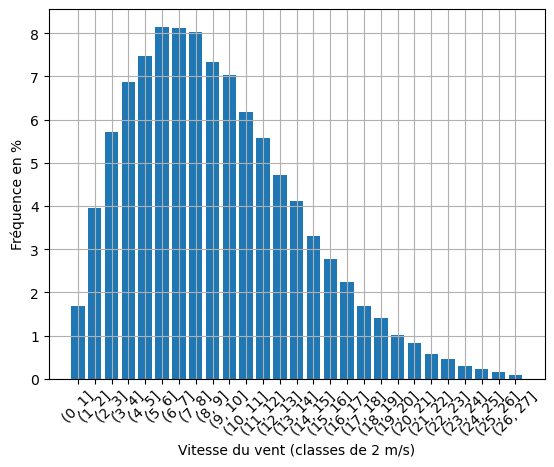

In [ ]:
df["classe_vitesse"] = pd.cut(df["Vitess_Vent_[m/s]"], bins=range(0, 28, 1))

# Calcul des fréquences normalisées
frequence = df["classe_vitesse"].value_counts(normalize=True).sort_index()*100

# Affichage
plt.bar(frequence.index.astype(str), frequence.values)
plt.xticks(rotation=45)
plt.xlabel("Vitesse du vent (classes de 2 m/s)")
plt.ylabel("Fréquence en %")
plt.grid(True)
plt.show()
 